In [530]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [532]:
def clean_data(train_data, test_data):
    #Iterate through both training and test data
    for df in [train_data, test_data]:
        #Iterate through each column in the data frames
        for col in df.columns: 
            
            #Fill in missing '?' values with suitable values
            df[col] = df[col].replace('?', np.nan) #Initially replace '?' with NaN
            #Consider each data type (categorical or numerical)
            if df[col].dtype == 'object': #Categorical
                #Fill NaN values with mode (most frequent value)
                df[col] = df[col].fillna(df[col].mode()[0]) 
            elif df[col].dtype in ['int64', 'float64']: #Numerical
                #Fill NaN values with mean (average numerical value)
                df[col] = df[col].fillna(df[col].mean()) 

            #Remove outliers from 'capital.gain' and 'capital.loss' columns
            if col in ['capital.gain', 'capital.loss']:
                #Identify outliers (99th and 1st percentiles)
                upper_bound = df[col].quantile(0.99) 
                lower_bound = df[col].quantile(0.01)
                #Calculate mean excluding outliers
                col_mean = df[col][(df[col] >= lower_bound) & (df[col] <= upper_bound)].mean()
                #Replace outliers with the calculated mean
                df[col] = np.where((df[col] < lower_bound) | (df[col] > upper_bound), col_mean, df[col])
   
        #Drop unnecessary columns
        df.drop(['education.num', 'fnlwgt'], axis=1, inplace=True)

        #Simplify 'race' and 'education' columns by mapping and .replace()
        race_mapping = {'Black': 'Other',
                        'Asian-Pac-Islander': 'Other',
                        'Amer-Indian-Eskimo': 'Other',
                        'Other': 'Other'}
        df['race'] = df['race'].replace(race_mapping)

        education_mapping = {'11th': 'School',
                             '9th': 'School',
                             '7th-8th': 'School',
                             '5th-6th': 'School',
                             '10th': 'School',
                             '1st-4th': 'School',
                             'Preschool': 'School',
                             '12th': 'School'}
        df['education'] = df['education'].replace(education_mapping)

        #Convert 'income' column to binary values
        df['income'] = df['income'].replace({'<=50K': 0, '>50K': 1})

    #Save cleaned data to 'cleaned_train_data.csv and cleaned_test_data.csv files
    train_filename = 'cleaned_train_data.csv'
    test_filename = 'cleaned_test_data.csv'
    for df, filename in [(train_data, train_filename), (test_data, test_filename)]:
        df.to_csv(filename, index=False)
        
    return train_data, test_data

In [534]:
def plot_numeric_feature_correlation(train_data):
    #Select numeric features
    numeric_cols = train_data.select_dtypes(include=['number']).columns
    #Create new dataframe for correlation matrix
    correlation_data = train_data[numeric_cols]

    #Compute correlation matrix
    corr_matrix = correlation_data.corr()

    #Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot = True, cmap = 'Oranges')
    plt.title('Correlation Between Numerical Features')

In [566]:
def plot_histogram(train_data):
    #Create categories for income column (0 or 1)
    income_categories = train_data['income'].unique()

    #Plot histogram showing distribution between each column and income category
    for col in train_data.columns:
        plt.figure(figsize=(10, 6))
        plt.title(f"Distribution of {col} by Income")
        plt.xlabel(col)
        plt.ylabel("Number of Samples")

        for income in income_categories:
            subset = train_data[train_data['income'] == income]
            sns.histplot(subset[col], alpha=1.0, label=f'{ "<=50K" if income == 0 else ">50K"}', shrink=0.15, bins=10)
            
            plt.legend()

In [568]:
# Load data
train_data = pd.read_csv('train_data.csv')
test_data = pd.read_csv('test_data.csv')

In [570]:
clean_data(train_data, test_data)

/var/folders/th/0mc1t9bn5y93bp8xb3l9pc140000gn/T/ipykernel_5818/2450260123.py:48: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income'] = df['income'].replace({'<=50K': 0, '>50K': 1})
/var/folders/th/0mc1t9bn5y93bp8xb3l9pc140000gn/T/ipykernel_5818/2450260123.py:48: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income'] = df['income'].replace({'<=50K': 0, '>50K': 1})


(       age         workclass     education      marital.status  \
 0       48           Private  Some-college  Married-civ-spouse   
 1       54           Private       HS-grad  Married-civ-spouse   
 2       43           Private       HS-grad  Married-civ-spouse   
 3       32           Private     Assoc-voc       Never-married   
 4       43         State-gov     Bachelors  Married-civ-spouse   
 ...    ...               ...           ...                 ...   
 26044   34  Self-emp-not-inc       HS-grad  Married-civ-spouse   
 26045   23           Private  Some-college       Never-married   
 26046   44       Federal-gov  Some-college  Married-civ-spouse   
 26047   23           Private       HS-grad       Never-married   
 26048   31           Private       HS-grad  Married-civ-spouse   
 
               occupation   relationship   race     sex  capital.gain  \
 0           Craft-repair        Husband  White    Male           0.0   
 1                  Sales        Husband  White 

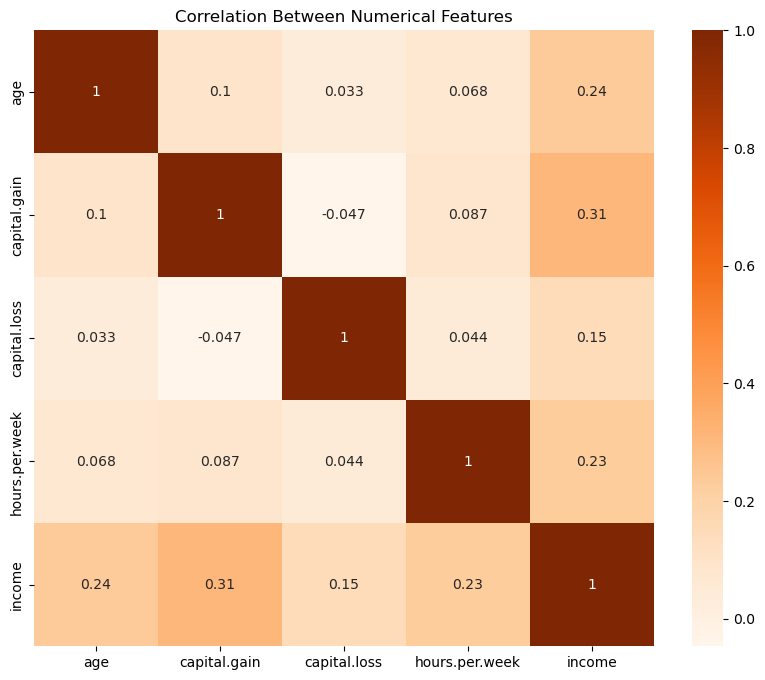

In [572]:
plot_numeric_feature_correlation(train_data)

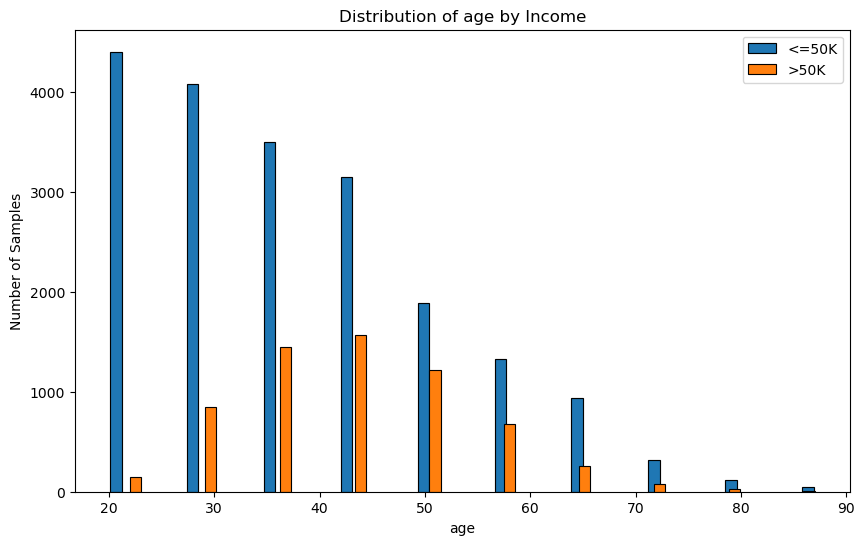

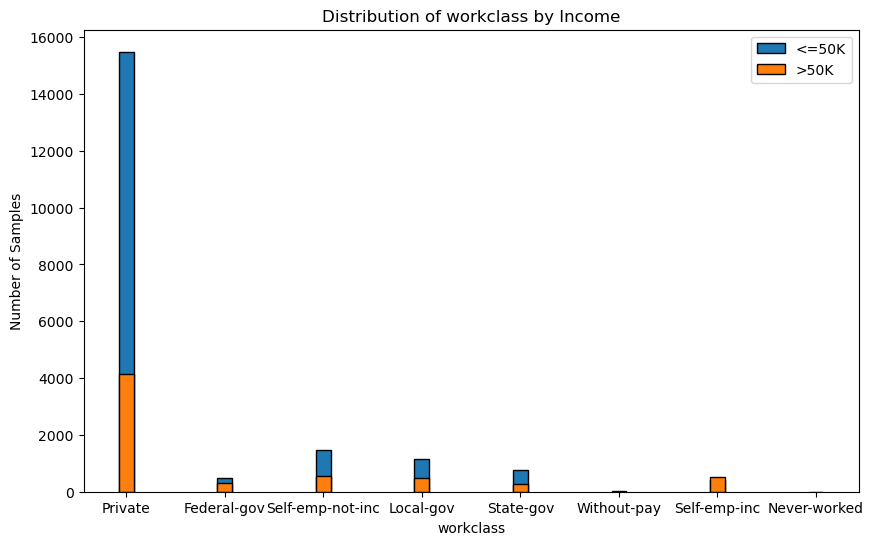

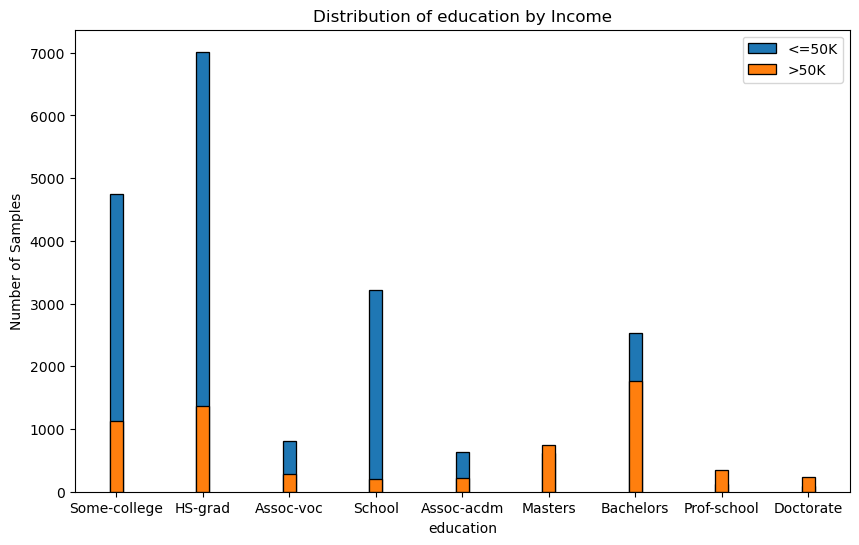

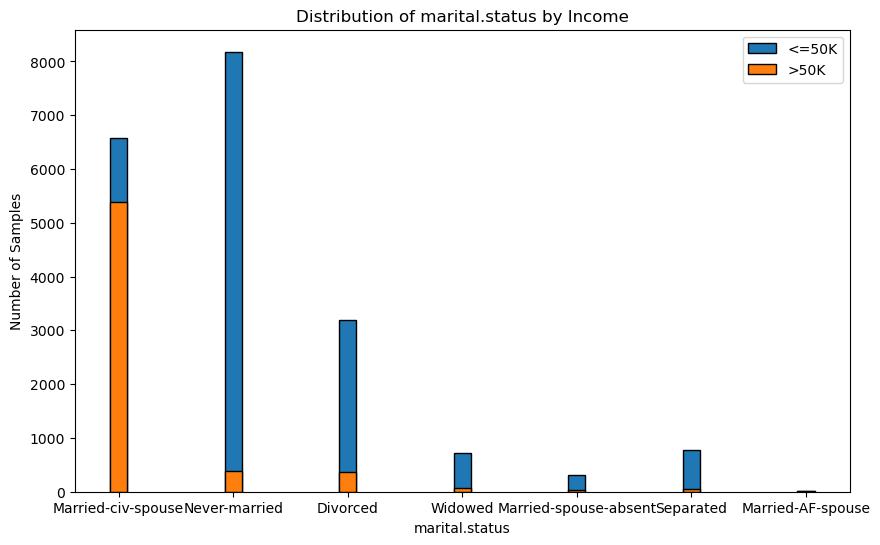

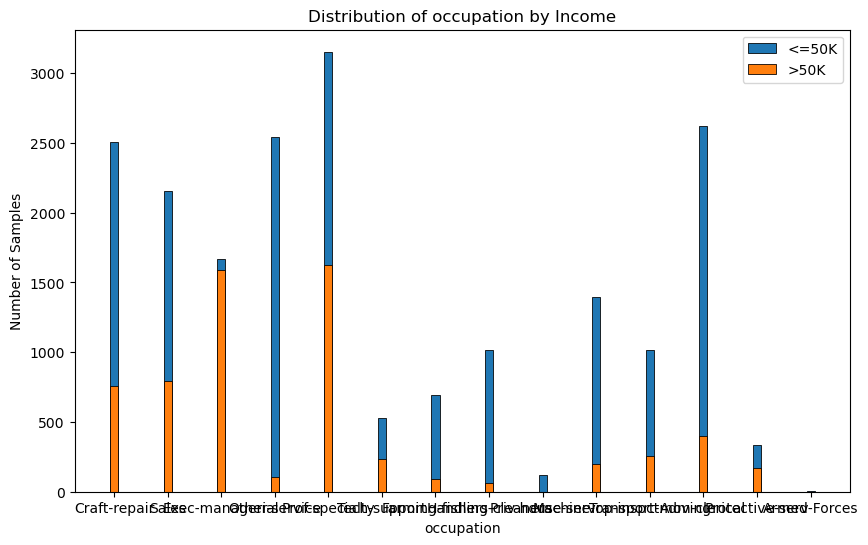

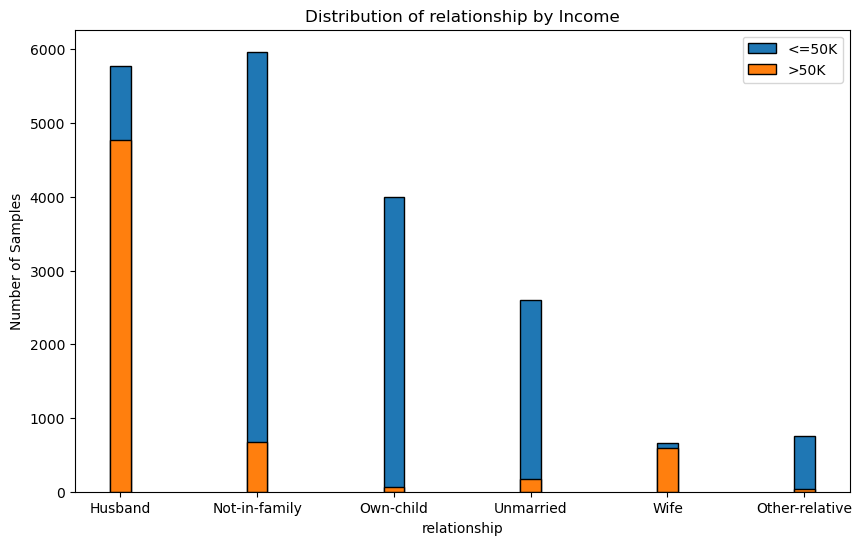

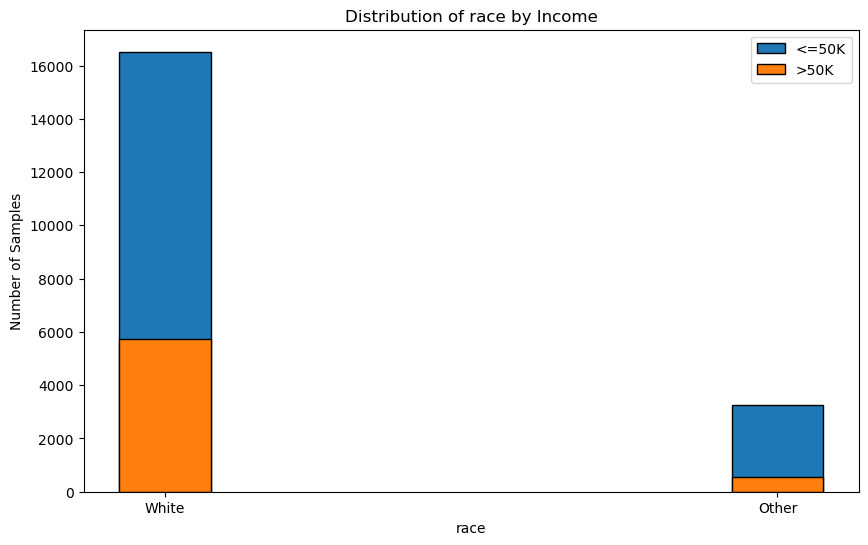

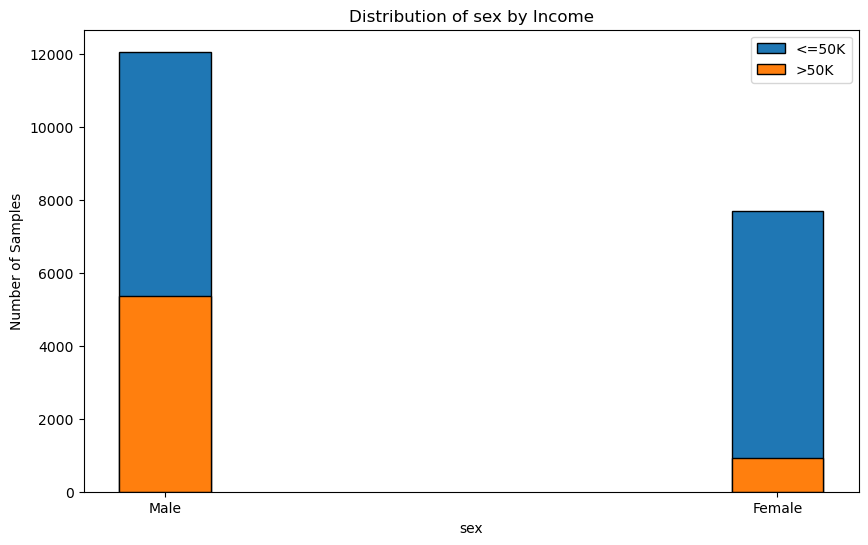

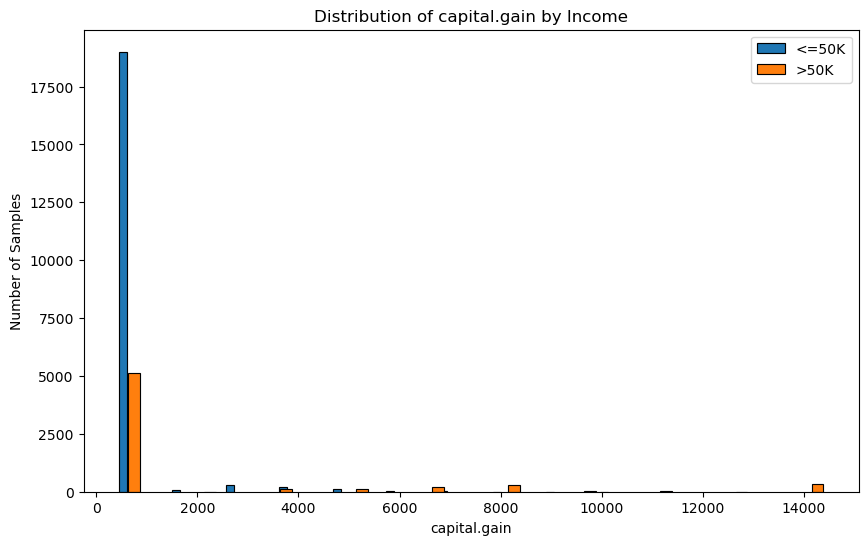

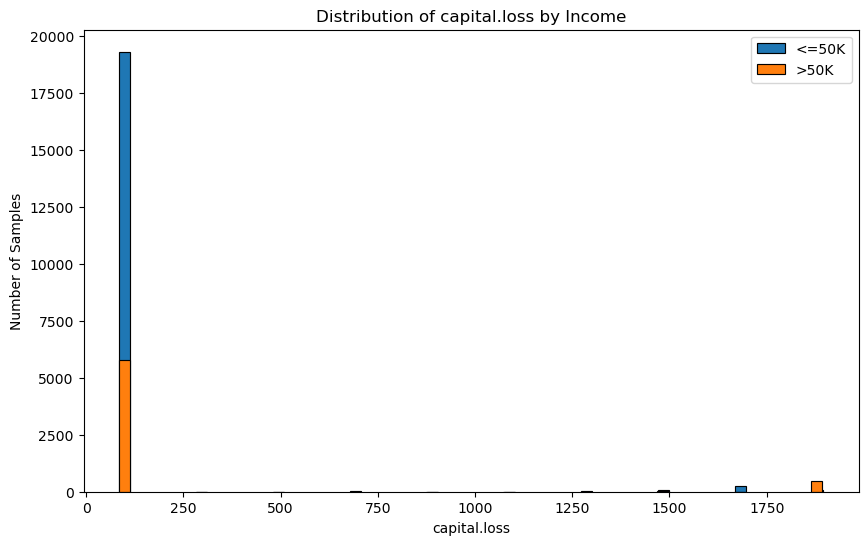

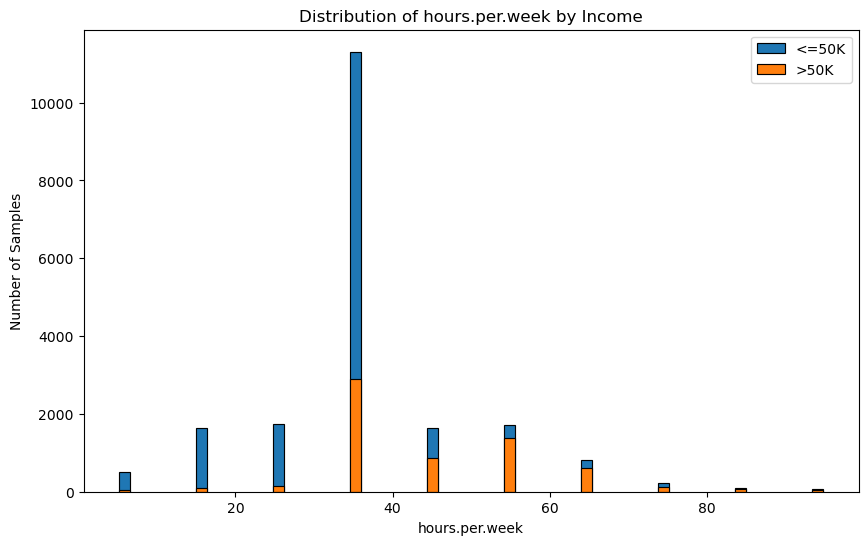

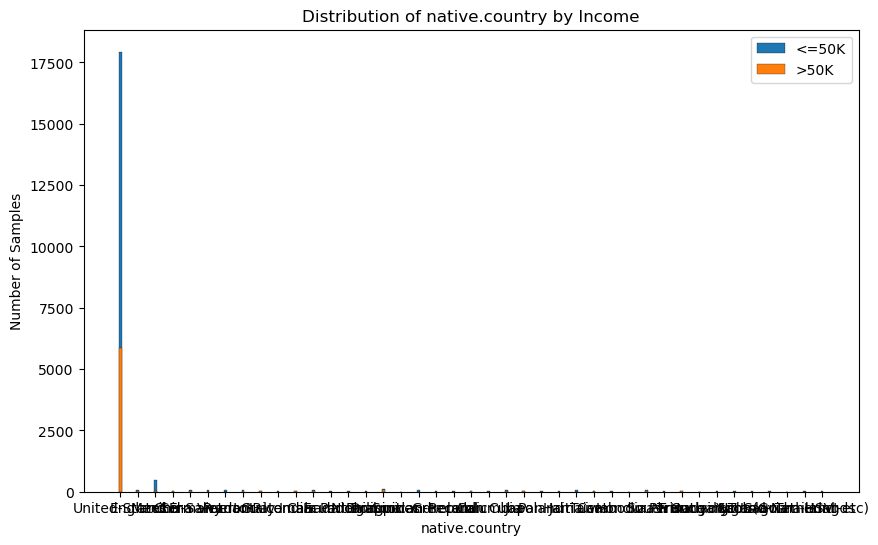

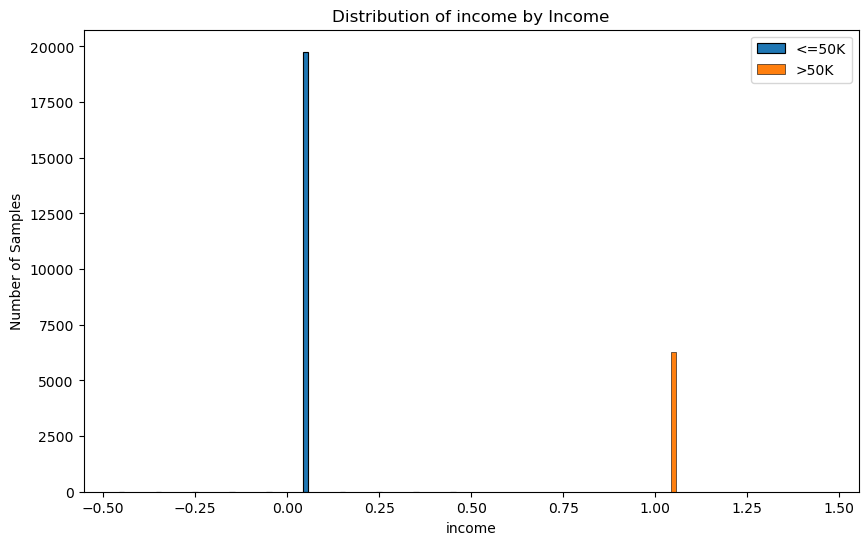

In [574]:
plot_histogram(train_data)